In [27]:
import numpy as np
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse
import xgboost as xgb

In [28]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
by_day_data_list = [x for x in os.listdir(by_day_data) if 'train.csv' in x]
dtypes = pd.read_csv(f'{os.path.join(by_day_data,by_day_data_list[0])}', nrows=1).iloc[0].to_dict()

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path,
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [29]:
daily_df = read_csv(by_day_data+by_day_data_list[0])
daily_df = daily_df[daily_df['date'].between(pd.Timestamp('2024-07-30'), pd.Timestamp('2025-09-01'), inclusive='left')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [30]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,11.92,30.13,0


In [31]:
# I want to add daily weather data.
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [32]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
197,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
198,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
199,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
200,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
201,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [33]:
daily_df = pd.merge(daily_df, weather, on='date')

In [34]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2024-07-30,E,Indian Rd,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
1,2024-07-30,E,Coxwell Ave at Gerrard St East,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
2,2024-07-30,E,Grace St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
3,2024-07-30,W,Woodbine Ave,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0
4,2024-07-30,E,De Grassi St,0,0,0.0,0.0,16.4,153.4,10.6,...,20100,2.8,7.4,7.4,0.0,0.0,0 days 06:05:00,0 days 20:42:00,14.62,5.0


In [35]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

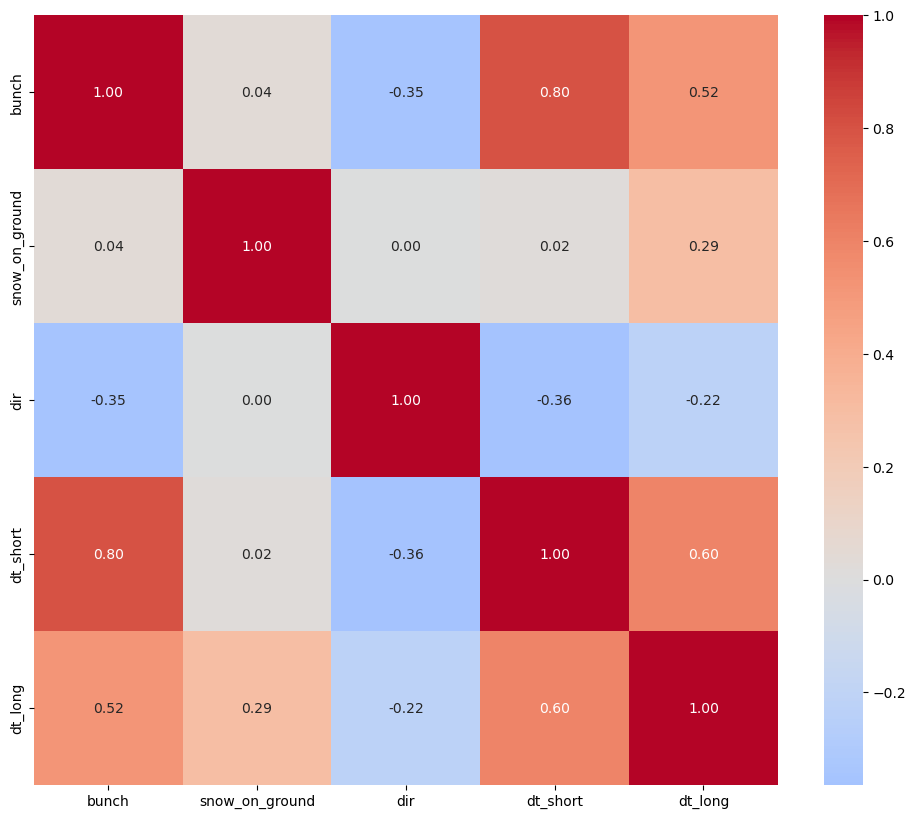

In [36]:
features = ['bunch', 'snow_on_ground','dir']

daily_df['stop'] = daily_df['stop'].astype('category').cat.codes
daily_df['dir'] = daily_df['dir'].astype('category').cat.codes
targets = [x for x in daily_df.columns if 'dt_' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

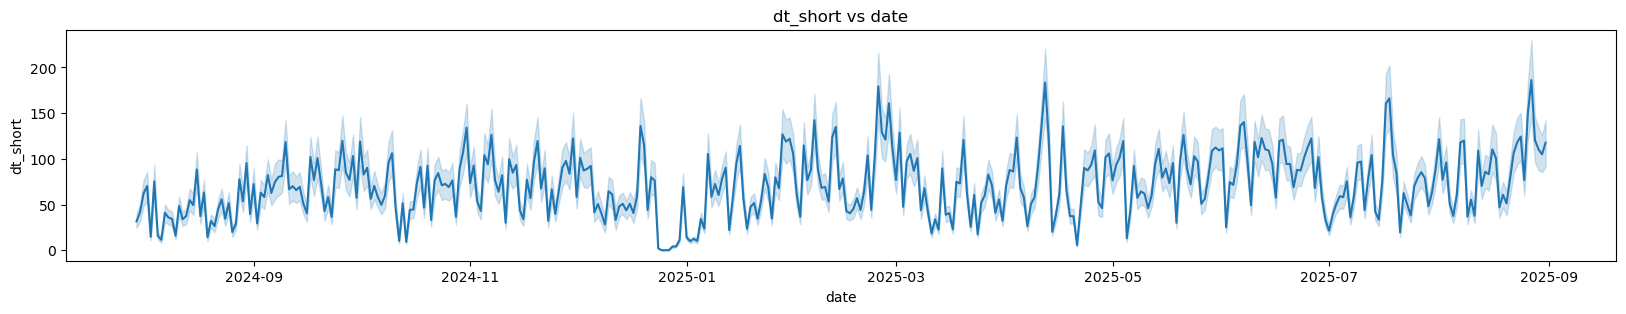

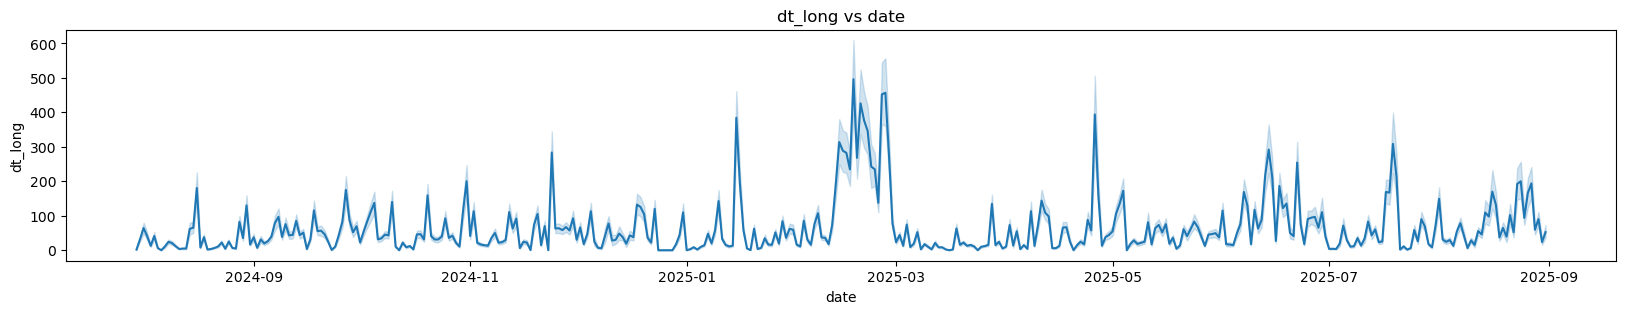

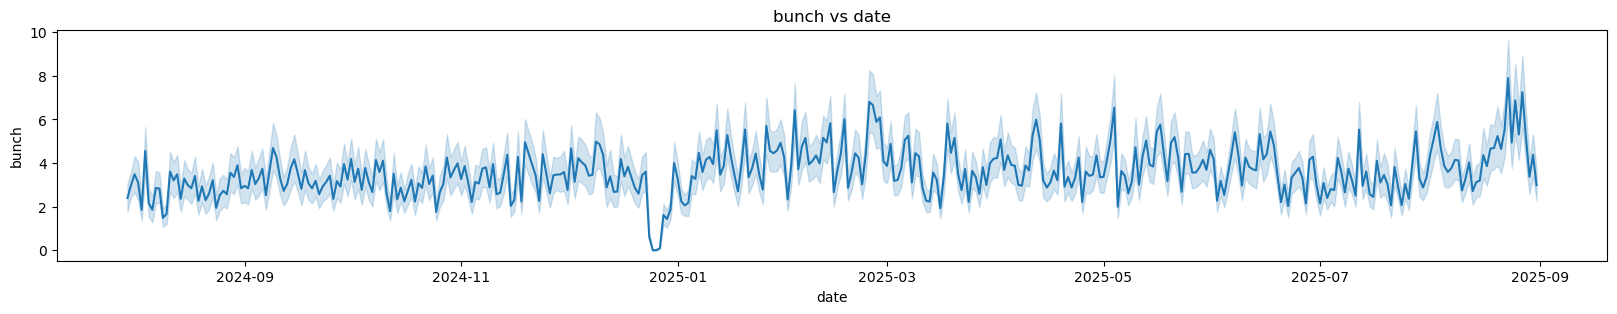

In [37]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20, 3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(f'{dt} vs date')
    plt.show()

plt.figure(figsize=(20, 3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch vs date')
plt.show()

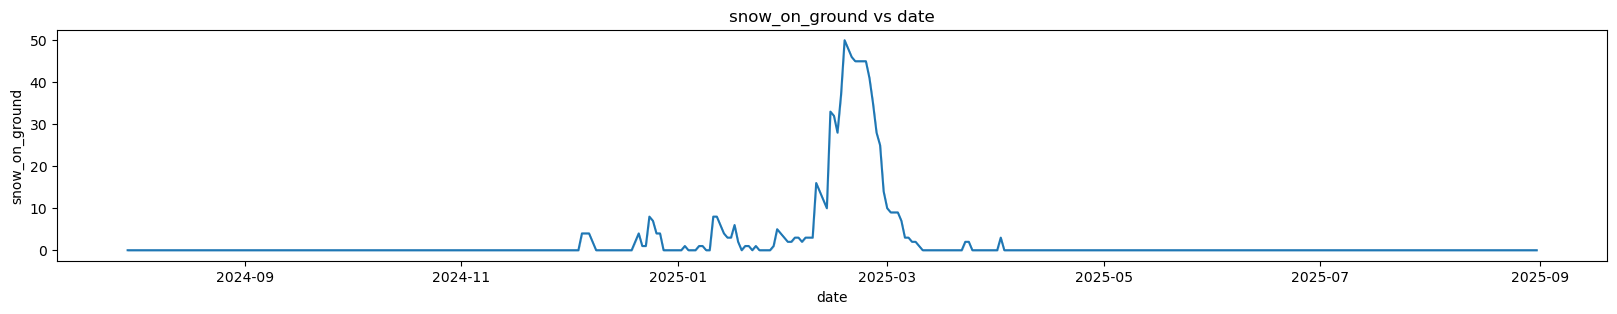

In [38]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.title('snow_on_ground vs date')
plt.show()

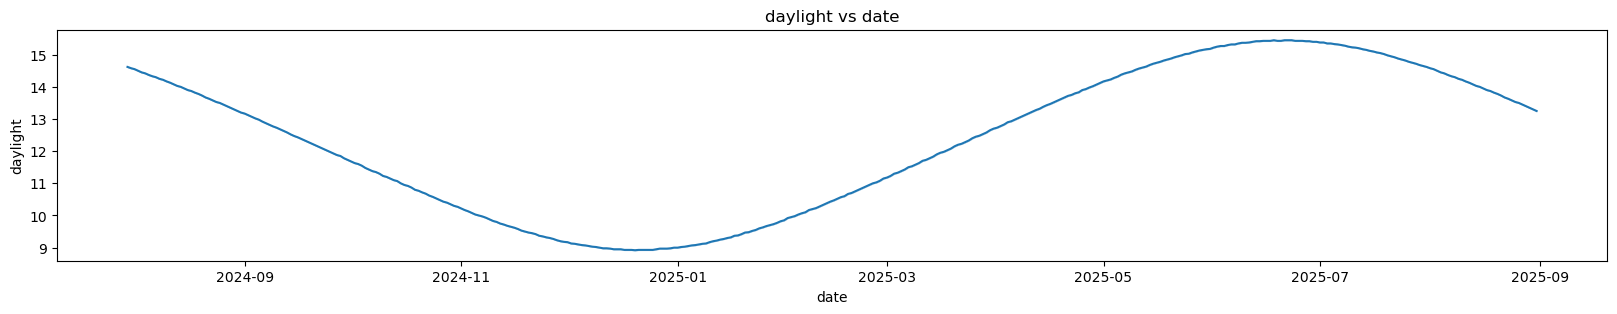

In [39]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.title('daylight vs date')
plt.show()

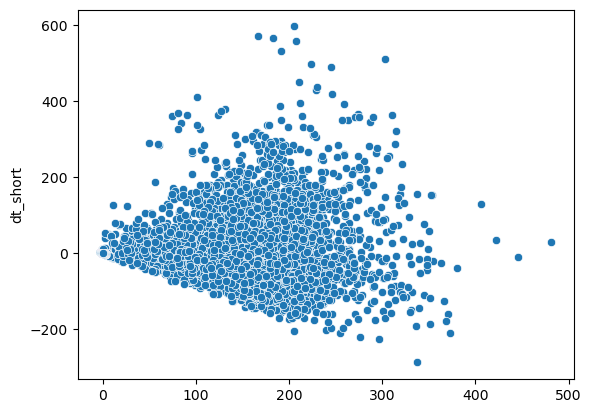

count    9684.000000
mean       71.983619
std       111.315446
min         0.000000
25%         0.000000
50%         0.000000
75%       120.529167
max       812.733333
Name: dt_short, dtype: float64


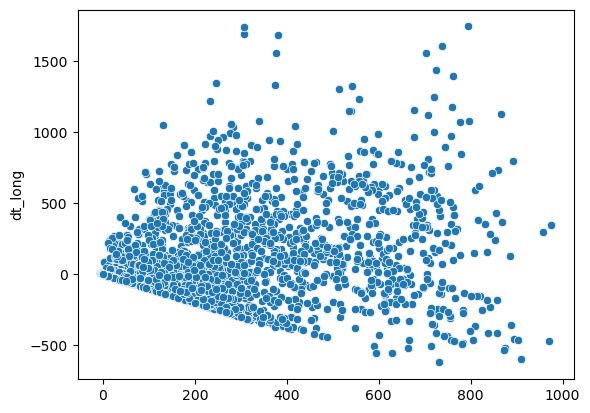

count    9684.000000
mean       93.014238
std       248.269730
min         0.000000
25%         0.000000
50%         0.000000
75%        39.875000
max      2535.166667
Name: dt_long, dtype: float64
dt_short rmse mean: 59.930190436872316
dt_short rmse std: 5.3695351652885535
dt_short average R^2 score: 0.7146724698233187
dt_short R^2 score std: 0.03314917307447432

dt_long rmse mean: 129.10308802014177
dt_long rmse std: 24.111996407772995
dt_long average R^2 score: 0.38074413694971526
dt_long R^2 score std: 0.11827922885709946



In [40]:
# Let's try xgboost since it is a very flexible model

# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain',
            'snow_on_ground',
            'daylight', 'dir', 'stop']



tss = TimeSeriesSplit(n_splits=5)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]
        
        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.7,
                                max_depth=6,
                                reg_alpha=4,
                                reg_lambda=5)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)
        if idx ==2:
            y_resid = y_test-y_pred
            sns.scatterplot(x=y_pred, y=y_resid)
            plt.show()
            
            print(y_test.describe())


for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

That gap seems to be so dominant is very suspicious, especially since gapping events are defined as gaps between streetcars that are at least 19 minutes long. Therefore, we rerun the model without it.

In [41]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
lambda_vals = [0,1,2,3,5,7,10]
alpha_vals = [0,1,2,3,4,5,7,10]
depth_vals = [5,10]
est_vals = [100]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

KeyboardInterrupt: 

In [ ]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

70.82457651705802 (10, 10, 5, 100) 0.635543081430118 (2, 5, 5, 100)
[59.08549127317301, 66.42544852929394, 69.75517609001108, 75.11082808397735, 70.82457651705802]
[0.7068495810873674, 0.5713632063477156, 0.6072765197234697, 0.6076514932488555, 0.6519047070626629]
[58.7728269412283, 67.16420633644888, 68.53592611149473, 72.05372714551137, 71.405537384954]
[0.7099439165723119, 0.5617759273090325, 0.6208853558246663, 0.638939644658495, 0.6461705627860839]


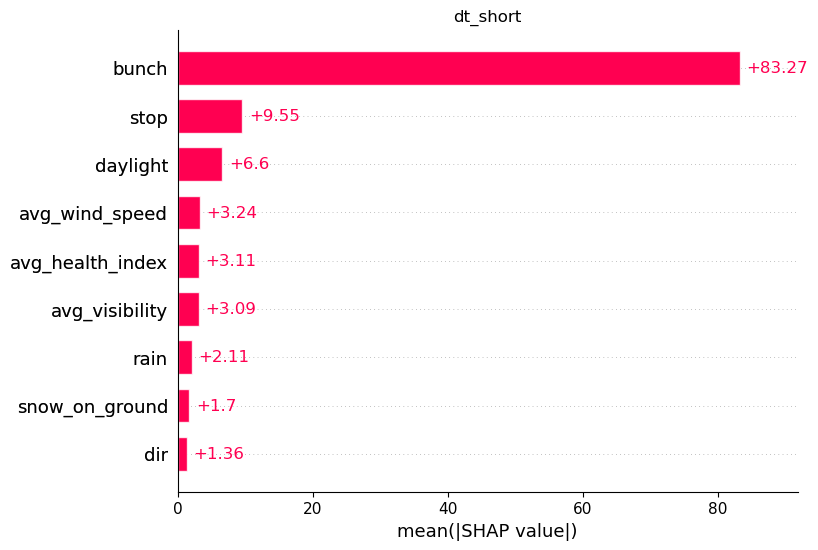

In [ ]:
import shap
shap.initjs()

df_filter = dict()
y_filter = dict()
X_filter= dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
for target in ['dt_short']:
    df_filter[target] = daily_df
    X_filter[target] = df_filter[target][[x for x in features]]
    y_filter[target] = df_filter[target][target]

model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,
    subsample=0.8,
    max_depth=5,
    reg_lambda=2,
    reg_alpha=5,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])


explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

Finally, we compare the performace with test data.

In [42]:
by_day_data = '../data/schedule_data/processed_data/by_day_short_and_long/'
test_data_list = [x for x in os.listdir(by_day_data) if 'test.csv' in x]
test_df = read_csv(by_day_data+test_data_list[0])

test_df = test_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

# I want to add daily weather data.
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [43]:
first_date = test_df['date'].min()
last_date = test_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]

In [44]:
test_df = pd.merge(test_df, weather, on='date')

In [45]:
# Fill na values with 0 and prune outliers
test_df.fillna(0, inplace=True)


72.0274276909317
0.4268147220894414


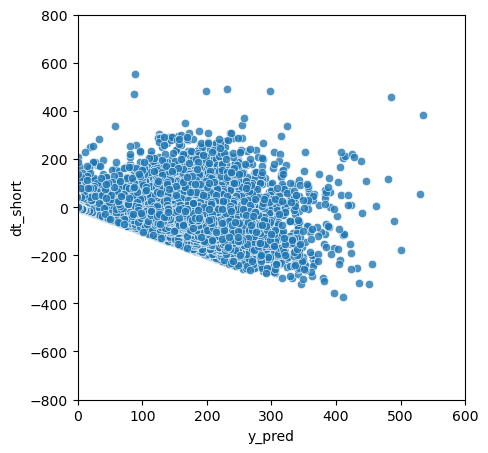

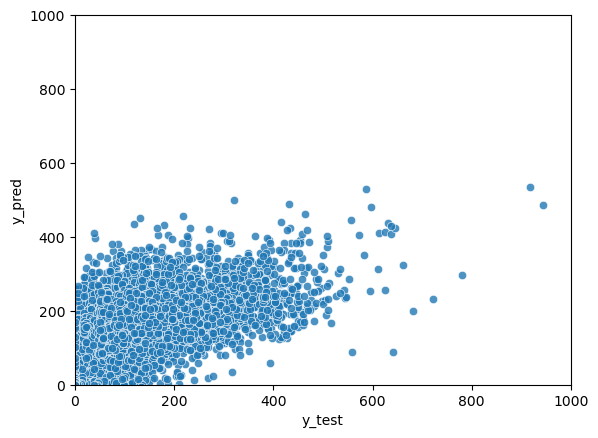

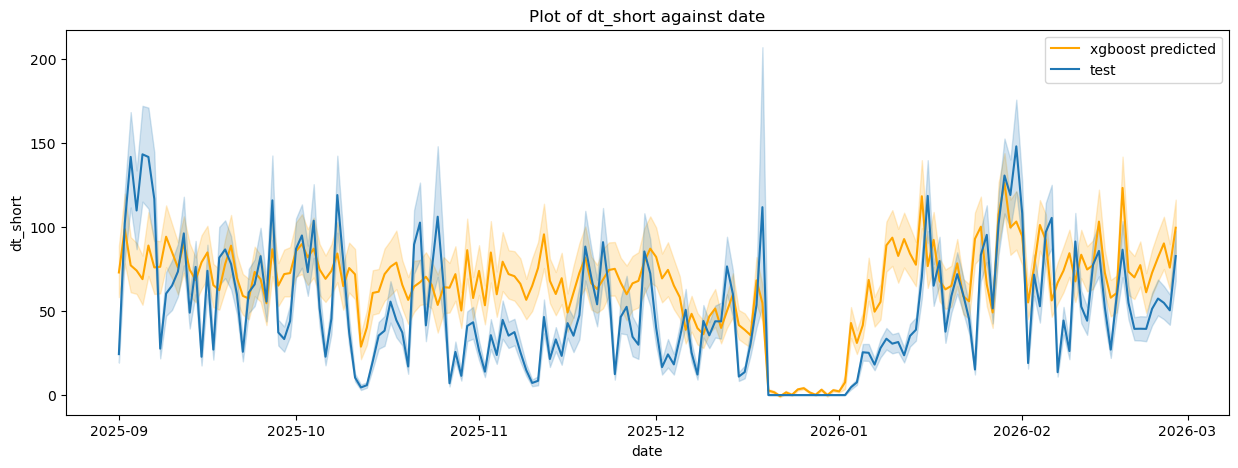

In [46]:
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

test_df['stop']=test_df['stop'].astype('category')
test_df['dir']=test_df['dir'].astype('category')

X_test = test_df[[x for x in features]]
y_test = test_df['dt_short']

X_train = daily_df[[x for x in features]]
y_train = daily_df['dt_short']

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=100,
                        enable_categorical=True,
                        learning_rate=0.1,
                        subsample=0.7,
                        max_depth=5,
                        reg_lambda=1,
                        reg_alpha=10,
                        seed=37)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(rmse(y_test,y_pred))
print(r2_score(y_test,y_pred))

plt.figure(figsize=(5, 5))
y_resid = y_test-y_pred
sns.scatterplot(x=y_pred, y=y_resid, alpha=0.8)
plt.ylim(-800,800)
plt.xlim(0,600)
plt.xlabel('y_pred')
plt.ylabel
plt.show()

sns.scatterplot(x=y_test, y=y_pred, alpha=0.8)
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.xlim(0,1000)
plt.ylim(0,1000)
plt.show()


plt.figure(figsize=(15,5))
sns.lineplot(x=test_df['date'], y=y_pred, color='orange', label='xgboost predicted')
sns.lineplot(x=test_df['date'], y=test_df['dt_short'], label='test')
plt.legend()
plt.ylabel('dt_short')
plt.xlabel('date')
plt.title('Plot of dt_short against date')
plt.show()

In [ ]:
loss = dict()
R2_score = dict()
features = ['bunch', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5)
target = 'dt_short'
lambda_vals = [0,1,2,3,4,5,6,7,10, 13, 15]
alpha_vals = [0,1,2,3,4,5,6,7,10, 13, 15]
depth_vals = [5,10,15]
est_vals = [100]

params = dict()
for l in lambda_vals:
    for a in alpha_vals:
        for d in depth_vals:
            for n in est_vals:
                params[l,a,d,n] = (l,a,d,n)

for param in params.keys():
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=param[3],
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=param[2],
                                reg_lambda=param[0],
                                reg_alpha=param[1],
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[param,idx] = r2_score(y_test, y_pred)
        loss[param,idx] = rmse(y_test, y_pred)

In [ ]:
best_loss = np.inf
best_R2 = 0
best_loss_param = (0,0,0,0)
best_R2_param = (0,0,0,0)
for param in params.keys():
    curr_loss = np.array([loss[param, idx] for idx in range(5)]).mean()
    curr_R2 = np.array([R2_score[param, idx] for idx in range(5)]).mean()
    if curr_loss < best_loss:
        best_loss = loss[param, idx]
        best_loss_param = param
    if curr_R2 > best_R2:
        best_R2 = curr_R2
        best_R2_param = param

print(best_loss, best_loss_param, best_R2, best_R2_param)
print([loss[best_loss_param, idx] for idx in range(5)])
print([R2_score[best_loss_param, idx] for idx in range(5)])

print([loss[best_R2_param, idx] for idx in range(5)])
print([R2_score[best_R2_param, idx] for idx in range(5)])

69.78312806554882 (15, 15, 5, 100) 0.6449471493531135 (4, 5, 5, 100)
[54.39961969327288, 67.7848768874997, 70.51021493181223, 71.16146315799784, 69.78312806554882]
[0.7515033464763492, 0.5536391667753258, 0.598728730400772, 0.6478265254233548, 0.6620666575571437]
[53.53376251073129, 68.49813505857979, 70.24764163758609, 69.73744189188716, 70.2328778227888]
[0.7593508382231682, 0.5441961897028633, 0.601711757417531, 0.6617802773327797, 0.6576966840892255]


count    26280.000000
mean        64.277321
std         89.451401
min        -10.224603
25%          0.105317
50%          1.782406
75%        142.453934
max        594.177429
dtype: float64
count    26280.000000
mean        49.876944
std         95.139016
min          0.000000
25%          0.000000
50%          0.000000
75%         77.841667
max       6355.766667
Name: dt_short, dtype: float64
71.87730776425046
0.4292015034960046


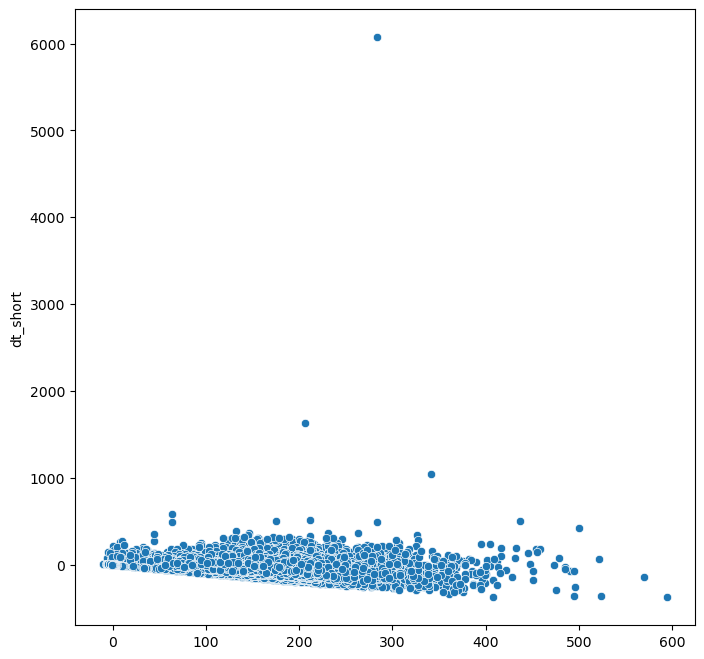

<Axes: ylabel='dt_short'>

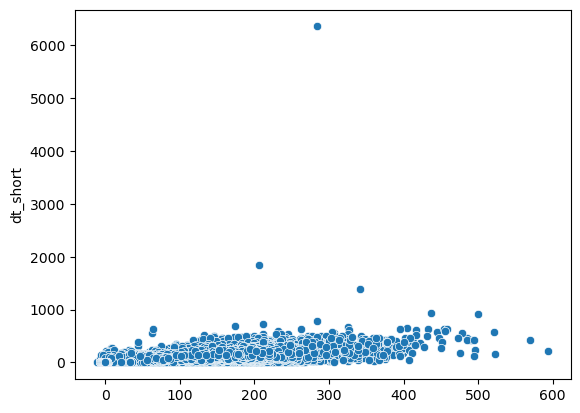

In [ ]:
test_df['stop']=test_df['stop'].astype('category')
test_df['dir']=test_df['dir'].astype('category')

features = ['bunch', 'daylight', 'dir', 'stop']

X_train = daily_df[[x for x in features]]
y_train = daily_df['dt_short']

X_test = test_df[[x for x in features]]
y_test = test_df['dt_short']

model =xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                subsample=0.8,
                                max_depth=5,
                                reg_lambda=4,
                                reg_alpha=5,
                                seed=37)


model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print(pd.Series(y_pred).describe())
print(pd.Series(y_test).describe())

print(rmse(y_test,y_pred))
print(r2_score(y_test,y_pred))


plt.figure(figsize=(8, 8))
y_resid = y_test-y_pred
sns.scatterplot(x=y_pred, y=y_resid)
plt.show()

sns.scatterplot(x=y_pred, y=y_test)


Finally, we check the quality of a baseline model.

In [ ]:
baseline = dict()

for stop in daily_df.stop.unique():
    for dir in ['E', 'W']:
        baseline[stop, dir] = daily_df[(daily_df['stop'] == stop) & (daily_df['dir'] == dir)][dt].mean()

baseline_df = test_df[['dir', 'stop']].copy()

dt_list = []

for row in range(baseline_df.shape[0]):
    curr_stop = baseline_df['stop'].iloc[row]
    curr_dir = baseline_df['dir'].iloc[row]

    dt_list.append(baseline[curr_stop, curr_dir])

baseline_df['dt_short'] = dt_list

rmse_baseline = rmse(test_df['dt_short'], baseline_df['dt_short'])
print(f'Performance of baseline model on dt_short RMSE: {rmse_baseline}')

Performance of baseline model on dt_short RMSE: 90.30585588802066


In [ ]:
rmse_baseline = rmse(test_df['dt_short'], baseline_df['dt_short'])
print(f'Performance of baseline model on dt_short RMSE: {rmse_baseline}')


Performance of baseline model on dt_short RMSE: 90.30585588802066


<Axes: xlabel='date', ylabel='dt_short'>

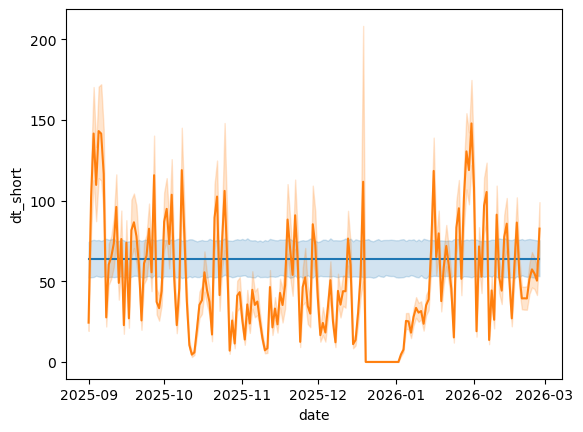

In [ ]:
sns.lineplot(x=test_df['date'], y= baseline_df['dt_short'])
sns.lineplot(x=test_df['date'], y=test_df['dt_short'])

In [ ]:
baseline = dict()

for stop in daily_df.stop.unique():
    for dir in ['E', 'W']:
        baseline[stop, dir] = 0

baseline_df = test_df[['dir', 'stop']].copy()

dt_list = []

for row in range(baseline_df.shape[0]):
    curr_stop = baseline_df['stop'].iloc[row]
    curr_dir = baseline_df['dir'].iloc[row]

    dt_list.append(baseline[curr_stop, curr_dir])

baseline_df['dt_short'] = dt_list

rmse_baseline = rmse(test_df['dt_short'], baseline_df['dt_short'])
print(f'Performance of baseline model on dt_short RMSE: {rmse_baseline}')

Performance of baseline model on dt_short RMSE: 107.41879460805626
